# Fair-BorderlineSMOTE: Gender-Aware Oversampling for Bias Mitigation in Recidivism Prediction

| | |
|---|---|
| **Dataset** | COMPAS Recidivism (ProPublica) |
| **Target** | `two_year_recid` — whether a defendant reoffended within two years |
| **Protected attribute** | `sex` (gender: Male / Female) |
| **Oversampling methods** | Baseline · SMOTE · BorderlineSMOTE · ADASYN · Fair-BorderlineSMOTE |
| **Classifiers** | Logistic Regression · Random Forest · XGBoost |

**Fair-BorderlineSMOTE** stratifies oversampling by gender × class subgroup, detects
borderline (danger-zone) samples using a kNN fitted on the full training set,
and synthesizes new samples exclusively from within each gender subgroup —
ensuring no cross-gender interpolation occurs.


In [ ]:
!pip install imbalanced-learn xgboost --quiet


In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (f1_score, roc_auc_score, accuracy_score,
                              precision_score, recall_score)
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

np.random.seed(42)
print('All imports successful.')


All imports successful.


---
## 1. Load COMPAS Dataset


In [ ]:
from google.colab import files
print('Upload compas-scores-two-years.csv')
print('Main Source: https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm')
print('Download Data Source: https://github.com/joymallyac/Fair-SMOTE/blob/master/data/compas-scores-two-years.csv')
uploaded = files.upload()


Upload compas-scores-two-years.csv
Main Source: https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm
Download Data Source: https://github.com/joymallyac/Fair-SMOTE/blob/master/data/compas-scores-two-years.csv


Saving compas-scores-two-years.csv to compas-scores-two-years (3).csv


In [ ]:
df_raw = pd.read_csv('compas-scores-two-years.csv')
# Show all columns
pd.set_option('display.max_columns', None)
df_raw.head()

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,8/14/2013,Male,4/18/1947,69,Greater than 45,Other,0,1,0,0,0,-1.0,8/13/2013 6:03,8/14/2013 5:41,13011352CF10A,8/13/2013,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,Low,8/14/2013,Risk of Violence,1,Low,8/14/2013,7/7/2014,7/14/2014,0,327,0,0
1,3,kevon dixon,kevon,dixon,1/27/2013,Male,1/22/1982,34,25 - 45,African-American,0,3,0,0,0,-1.0,1/26/2013 3:45,2/5/2013 5:36,13001275CF10A,1/26/2013,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,7/5/2013,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),7/5/2013,Felony Battery (Dom Strang),Risk of Recidivism,Low,1/27/2013,Risk of Violence,1,Low,1/27/2013,1/26/2013,2/5/2013,9,159,1,1
2,4,ed philo,ed,philo,4/14/2013,Male,5/14/1991,24,Less than 25,African-American,0,4,0,1,4,-1.0,4/13/2013 4:58,4/14/2013 7:02,13005330CF10A,4/13/2013,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,6/16/2013,Driving Under The Influence,6/16/2013,6/16/2013,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,Low,4/14/2013,Risk of Violence,3,Low,4/14/2013,6/16/2013,6/16/2013,0,63,0,1
3,5,marcu brown,marcu,brown,1/13/2013,Male,1/21/1993,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,1/12/2013,NaN,1.0,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,High,1/13/2013,Risk of Violence,6,Medium,1/13/2013,NaN,NaN,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,3/26/2013,Male,1/22/1973,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,1/9/2013,76.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,Low,3/26/2013,Risk of Violence,1,Low,3/26/2013,NaN,NaN,0,1102,0,0


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7214 entries, 0 to 7213
Data columns (total 51 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       7214 non-null   int64  
 1   name                     7214 non-null   object 
 2   first                    7214 non-null   object 
 3   last                     7214 non-null   object 
 4   compas_screening_date    7214 non-null   object 
 5   sex                      7214 non-null   object 
 6   dob                      7214 non-null   object 
 7   age                      7214 non-null   int64  
 8   age_cat                  7214 non-null   object 
 9   race                     7214 non-null   object 
 10  juv_fel_count            7214 non-null   int64  
 11  decile_score             7214 non-null   int64  
 12  juv_misd_count           7214 non-null   int64  
 13  juv_other_count          7214 non-null   int64  
 14  priors_count            

In [ ]:
# Check missing value
df_raw.isnull().sum()

,0
id,0
name,0
first,0
last,0
compas_screening_date,0
sex,0
dob,0
age,0
age_cat,0
race,0


In [ ]:
# Standard ProPublica filtering
df = df_raw[
    (df_raw['days_b_screening_arrest'] <= 30) &
    (df_raw['days_b_screening_arrest'] >= -30) &
    (df_raw['is_recid'] != -1) &
    (df_raw['c_charge_degree'] != 'O') &
    (df_raw['score_text'] != 'N/A')
].copy()
df.head()

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,8/14/2013,Male,4/18/1947,69,Greater than 45,Other,0,1,0,0,0,-1.0,8/13/2013 6:03,8/14/2013 5:41,13011352CF10A,8/13/2013,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,Low,8/14/2013,Risk of Violence,1,Low,8/14/2013,7/7/2014,7/14/2014,0,327,0,0
1,3,kevon dixon,kevon,dixon,1/27/2013,Male,1/22/1982,34,25 - 45,African-American,0,3,0,0,0,-1.0,1/26/2013 3:45,2/5/2013 5:36,13001275CF10A,1/26/2013,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,7/5/2013,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),7/5/2013,Felony Battery (Dom Strang),Risk of Recidivism,Low,1/27/2013,Risk of Violence,1,Low,1/27/2013,1/26/2013,2/5/2013,9,159,1,1
2,4,ed philo,ed,philo,4/14/2013,Male,5/14/1991,24,Less than 25,African-American,0,4,0,1,4,-1.0,4/13/2013 4:58,4/14/2013 7:02,13005330CF10A,4/13/2013,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,6/16/2013,Driving Under The Influence,6/16/2013,6/16/2013,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,Low,4/14/2013,Risk of Violence,3,Low,4/14/2013,6/16/2013,6/16/2013,0,63,0,1
5,7,marsha miles,marsha,miles,11/30/2013,Male,8/22/1971,44,25 - 45,Other,0,1,0,0,0,0.0,11/30/2013 4:50,12/1/2013 12:28,13022355MM10A,11/30/2013,NaN,0.0,M,Battery,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,Low,11/30/2013,Risk of Violence,1,Low,11/30/2013,11/30/2013,12/1/2013,1,853,0,0
6,8,edward riddle,edward,riddle,2/19/2014,Male,7/23/1974,41,25 - 45,Caucasian,0,6,0,0,14,-1.0,2/18/2014 5:08,2/24/2014 12:18,14002304CF10A,2/18/2014,NaN,1.0,F,Possession Burglary Tools,1,14004485CF10A,(F2),0.0,3/31/2014,Poss of Firearm by Convic Felo,3/31/2014,4/18/2014,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,Medium,2/19/2014,Risk of Violence,2,Low,2/19/2014,3/31/2014,4/18/2014,5,40,1,1


In [ ]:
keep_cols = ['age', 'sex', 'race', 'juv_fel_count', 'juv_misd_count',
             'juv_other_count', 'priors_count', 'c_charge_degree',
             'two_year_recid']
df = df[keep_cols].dropna()
df['sex']  = df['sex'].str.strip()
df['race'] = df['race'].str.strip()
df = df[df['sex'].isin(['Male', 'Female'])].reset_index(drop=True)
df.head()

,age,sex,race,juv_fel_count,juv_misd_count,juv_other_count,priors_count,c_charge_degree,two_year_recid
0,69,Male,Other,0,0,0,0,F,0
1,34,Male,African-American,0,0,0,0,F,1
2,24,Male,African-American,0,0,1,4,F,1
3,44,Male,Other,0,0,0,0,M,0
4,41,Male,Caucasian,0,0,0,14,F,1


In [ ]:
print(f'COMPAS — shape: {df.shape}')
print(f'\nTarget (two_year_recid):')
print(df['two_year_recid'].value_counts())
print(f'\nGender (sex):')
print(df['sex'].value_counts())
print(f'\nGender x Class breakdown:')
print(df.groupby(['sex', 'two_year_recid']).size().unstack(fill_value=0))
print(f'\nOverall positive rate : {df["two_year_recid"].mean()*100:.1f}%')
print(f'Positive rate — Male  : {df[df["sex"]=="Male"]["two_year_recid"].mean()*100:.1f}%')
print(f'Positive rate — Female: {df[df["sex"]=="Female"]["two_year_recid"].mean()*100:.1f}%')

COMPAS — shape: (6172, 9)

Target (two_year_recid):
two_year_recid
0    3363
1    2809
Name: count, dtype: int64

Gender (sex):
sex
Male      4997
Female    1175
Name: count, dtype: int64

Gender x Class breakdown:
two_year_recid     0     1
sex                       
Female           762   413
Male            2601  2396

Overall positive rate : 45.5%
Positive rate — Male  : 47.9%
Positive rate — Female: 35.1%


## Target & gender distribution

  COMPAS Dataset — Descriptive Statistics

── Target: two_year_recid ──


,Label,Count,Percent
0,No recidivism,3363,54.49%
1,Recidivism,2809,45.51%



── Gender: sex ──


,Count,Percent
sex,,
Male,4997,80.96%
Female,1175,19.04%



── Gender breakdown within each class of two_year_recid ──


,Female Count,Female %,Male Count,Male %,Total
two_year_recid,,,,,
No recidivism (0),762,22.66%,2601,77.34%,3363
Recidivism (1),413,14.70%,2396,85.30%,2809
Total,1175,0.00%,4997,0.00%,6172



── Target class breakdown within each gender ──


,No Recid (0) Count,No Recid (0) %,Recid (1) Count,Recid (1) %,Total
sex,,,,,
Female,762,64.85%,413,35.15%,1175
Male,2601,52.05%,2396,47.95%,4997
Total,3363,0.00%,2809,0.00%,6172


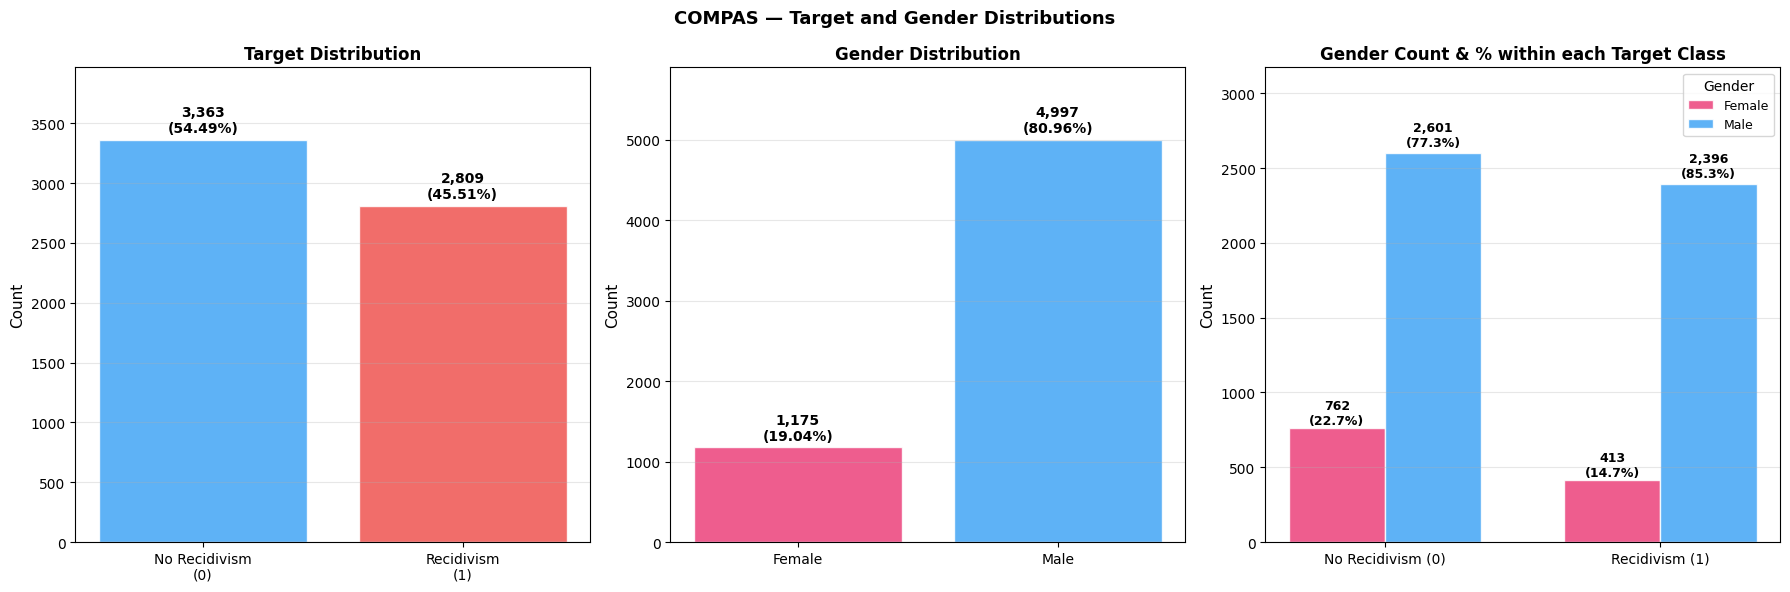

Saved plot_distributions.png


In [ ]:
# ==================================================================================
# Target distribution, gender distribution, and
# gender breakdown within each class of the target
# ==================================================================================

print('=' * 55)
print('  COMPAS Dataset — Descriptive Statistics')
print('=' * 55)

# ── 1. Target distribution ──
print('\n── Target: two_year_recid ──')
target_counts = df['two_year_recid'].value_counts().sort_index()
target_pct    = df['two_year_recid'].value_counts(normalize=True).sort_index() * 100
target_summary = pd.DataFrame({
    'Label':   {0: 'No recidivism', 1: 'Recidivism'},
    'Count':   target_counts,
    'Percent': target_pct.round(2),
})
target_summary['Percent'] = target_summary['Percent'].map('{:.2f}%'.format)
display(target_summary)

# ── 2. Gender distribution ──
print('\n── Gender: sex ──')
sex_counts = df['sex'].value_counts()
sex_pct    = df['sex'].value_counts(normalize=True) * 100
sex_summary = pd.DataFrame({
    'Count':   sex_counts,
    'Percent': sex_pct.round(2),
})
sex_summary['Percent'] = sex_summary['Percent'].map('{:.2f}%'.format)
display(sex_summary)

# ── 3. Gender percentage within each target class ──
print('\n── Gender breakdown within each class of two_year_recid ──')
cross = pd.crosstab(
    df['two_year_recid'], df['sex'],
    margins=True, margins_name='Total')
cross_pct = pd.crosstab(
    df['two_year_recid'], df['sex'],
    normalize='index') * 100

combined = pd.DataFrame(index=cross.index)
for gender in ['Female', 'Male']:
    if gender in cross.columns:
        combined[f'{gender} Count'] = cross[gender]
        combined[f'{gender} %']     = cross_pct[gender].reindex(
            cross.index).fillna(0).round(2).map('{:.2f}%'.format)
combined['Total'] = cross['Total']
combined.index    = combined.index.map(
    lambda x: {0: 'No recidivism (0)',
               1: 'Recidivism (1)',
               'Total': 'Total'}.get(x, x))
display(combined)

# ── 4. Target class percentage within each gender ──
print('\n── Target class breakdown within each gender ──')
cross_by_sex = pd.crosstab(
    df['sex'], df['two_year_recid'],
    margins=True, margins_name='Total')
cross_by_sex_pct = pd.crosstab(
    df['sex'], df['two_year_recid'],
    normalize='index') * 100

combined2 = pd.DataFrame(index=cross_by_sex.index)
for cls, label in [(0, 'No Recid (0)'), (1, 'Recid (1)')]:
    if cls in cross_by_sex.columns:
        combined2[f'{label} Count'] = cross_by_sex[cls]
        combined2[f'{label} %']     = cross_by_sex_pct[cls].reindex(
            cross_by_sex.index).fillna(0).round(2).map('{:.2f}%'.format)
combined2['Total'] = cross_by_sex['Total']
display(combined2)

# ── 5. Visual summary ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('COMPAS — Target and Gender Distributions',
             fontsize=13, fontweight='bold')


def label_bars(ax, bars, counts, pcts, fontsize=10):
    """Place count and percentage above each bar."""
    y_pad = ax.get_ylim()[1] * 0.01
    for bar, cnt, pct in zip(bars, counts, pcts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + y_pad,
            f'{int(cnt):,}\n({pct:.2f}%)',
            ha='center', va='bottom',
            fontsize=fontsize, fontweight='bold')


# ── Panel 1: Target distribution ──
target_bars = axes[0].bar(
    ['No Recidivism\n(0)', 'Recidivism\n(1)'],
    target_counts.values,
    color=['#42A5F5', '#EF5350'], alpha=0.85, edgecolor='white')
axes[0].set_title('Target Distribution', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, target_counts.max() * 1.18)
label_bars(axes[0], target_bars,
           target_counts.values, target_pct.values)

# ── Panel 2: Gender distribution ──
sex_order  = ['Female', 'Male']
sex_vals   = sex_counts.reindex(sex_order)
sex_pct_v  = sex_pct.reindex(sex_order)
sex_bars   = axes[1].bar(
    sex_order, sex_vals.values,
    color=['#EC407A', '#42A5F5'], alpha=0.85, edgecolor='white')
axes[1].set_title('Gender Distribution', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, sex_vals.max() * 1.18)
label_bars(axes[1], sex_bars,
           sex_vals.values, sex_pct_v.values)

# ── Panel 3: Grouped bar — gender count within each target class ──
cross_counts = pd.crosstab(df['two_year_recid'], df['sex'])
cross_pcts   = pd.crosstab(df['two_year_recid'], df['sex'],
                            normalize='index') * 100

class_labels = ['No Recidivism (0)', 'Recidivism (1)']
x   = np.arange(len(class_labels))
w   = 0.35
g_colors = ['#EC407A', '#42A5F5']

for i, gender in enumerate(['Female', 'Male']):
    counts = cross_counts[gender].values
    pcts   = cross_pcts[gender].values
    bars   = axes[2].bar(
        x + i * w, counts, width=w,
        label=gender, color=g_colors[i],
        alpha=0.85, edgecolor='white')
    # Numeric label: count + % on top of each bar
    y_pad = axes[2].get_ylim()[1] * 0.01
    for bar, cnt, pct in zip(bars, counts, pcts):
        axes[2].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + y_pad,
            f'{int(cnt):,}\n({pct:.2f}%)',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold')

axes[2].set_title('Gender Count & % within each Target Class',
                  fontweight='bold', fontsize=12)
axes[2].set_ylabel('Count', fontsize=11)
axes[2].set_xticks(x + w / 2)
axes[2].set_xticklabels(class_labels, fontsize=10)
axes[2].set_ylim(0, cross_counts.values.max() * 1.22)
axes[2].legend(title='Gender', fontsize=9)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plot_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved plot_distributions.png')

---
## 2. Preprocessing


In [ ]:
LABEL_COL = 'two_year_recid'
SEX_COL   = 'sex'

# Preserve raw gender strings for fairness evaluation
sex_raw = df[SEX_COL].values.copy()

# Label-encode all categorical columns
df_enc = df.copy()
for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col].astype(str))

FEAT_COLS = [c for c in df_enc.columns if c != LABEL_COL]

X_all   = df_enc[FEAT_COLS].values.astype(float)
y_all   = df_enc[LABEL_COL].values.astype(int)
sex_all = sex_raw[:len(X_all)]

# Stratified 80/20 split
X_tr, X_te, y_tr, y_te, sex_tr, sex_te = train_test_split(
    X_all, y_all, sex_all,
    test_size=0.2, random_state=42, stratify=y_all)

# StandardScaler fitted on train only, applied to test
scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc = scaler.transform(X_te)

print(f'Train: {len(X_tr_sc):,}  |  Test: {len(X_te_sc):,}')
print(f'Train class dist : {dict(pd.Series(y_tr).value_counts())}')
print(f'Train gender dist: {dict(pd.Series(sex_tr).value_counts())}')
print(f'Test  gender dist: {dict(pd.Series(sex_te).value_counts())}')
print(f'Feature columns ({len(FEAT_COLS)}): {FEAT_COLS}')


Train: 4,937  |  Test: 1,235
Train class dist : {0: np.int64(2690), 1: np.int64(2247)}
Train gender dist: {'Male': np.int64(3995), 'Female': np.int64(942)}
Test  gender dist: {'Male': np.int64(1002), 'Female': np.int64(233)}
Feature columns (8): ['age', 'sex', 'race', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count', 'c_charge_degree']


---
## 3. Fair-BorderlineSMOTE Implementation


Fair-BorderlineSMOTE iterates over every **(gender, class)** subgroup and:
1. Detects **borderline (danger-zone)** samples using a kNN fitted on the **full training set**: a sample is borderline if `0 < majority_neighbors < m`
2. Synthesizes new samples from borderline seeds only, using a kNN fitted **within the gender subgroup** — no cross-gender interpolation
3. Continues until each subgroup reaches `max_size` (the size of the largest subgroup)


In [ ]:
# ==============================================================================
# Vectorized synthesis core
# ==============================================================================
def _synthesize(sub_arr, seed_idx, knn_within, to_gen, cr=0.8, f=0.8):
    """
    Generate `to_gen` synthetic samples from `seed_idx` pool.
    Uses NumPy broadcasting — no Python loop over individual samples.

    Parameters
    ----------
    sub_arr    : ndarray (n_sub, n_feat)  subgroup feature matrix
    seed_idx   : 1-D array of borderline seed indices into sub_arr
    knn_within : NearestNeighbors fitted on sub_arr (within-group)
    to_gen     : number of synthetic samples to produce
    cr         : crossover rate — probability of using interpolated value [0,1]
    f          : scaling factor for interpolation direction  [0,1]

    Returns
    -------
    ndarray (to_gen, n_feat)
    """
    if len(seed_idx) == 0 or to_gen == 0:
        return np.empty((0, sub_arr.shape[1]))
    seed    = sub_arr[seed_idx]
    pi      = np.random.randint(0, len(seed), to_gen)   # random parent indices
    parents = seed[pi]
    k_q     = min(3, len(sub_arr))
    _, nbrs = knn_within.kneighbors(parents, n_neighbors=k_q)
    c1      = sub_arr[nbrs[:, 0]]
    c2      = sub_arr[nbrs[:, min(1, k_q - 1)]]
    cr_mask = np.random.rand(to_gen, sub_arr.shape[1]) < cr
    return np.where(cr_mask, parents + f * (c1 - c2), parents)

print('Synthesis core ready.')


Synthesis core ready.


In [ ]:
# ==============================================================================
# Fair-BorderlineSMOTE
# ==============================================================================
def fair_borderline_smote(X_tr, y_tr, sex_tr, k=5, m=10, cr=0.8, f=0.8):
    """
    Fair-BorderlineSMOTE stratified by gender.

    For each (gender, class) subgroup:
      1. Detect borderline samples: knn_full (full dataset) is used so that
         majority-class neighbors from OTHER gender groups are also counted,
         giving a fair picture of how borderline each sample is globally.
      2. Synthesize from borderline seeds using knn_within (within gender),
         so synthetic samples stay inside the subgroup's feature distribution.

    Parameters
    ----------
    X_tr, y_tr  : training features and labels
    sex_tr      : gender array aligned with X_tr (string: 'Male'/'Female')
    k           : within-group kNN neighbors for synthesis
    m           : full-dataset kNN neighbors for borderline detection
    cr, f       : crossover rate and scaling factor

    Returns
    -------
    X_aug, y_aug, sex_aug, log_df
    """
    X = np.array(X_tr, dtype=float)
    y = np.array(y_tr)
    s = np.array(sex_tr)

    m_act    = min(m, len(X) - 1)
    knn_full = NearestNeighbors(
        n_neighbors=m_act, algorithm='kd_tree', n_jobs=-1).fit(X)
    max_size = int(pd.Series(y).value_counts().max())

    Xs, ys, ss = [X], [y], [s]
    log = []

    for cl in sorted(np.unique(y)):
        for sv in sorted(np.unique(s)):
            mask   = (y == cl) & (s == sv)
            sub    = X[mask]
            to_gen = max(0, max_size - mask.sum())

            if len(sub) < 2 or to_gen == 0:
                log.append({'gender': sv, 'class': cl,
                            'subgroup_size': len(sub),
                            'borderline': 0, 'generated': 0})
                continue

            # Step 1: borderline detection (full-dataset kNN)
            _, idx = knn_full.kneighbors(sub, n_neighbors=m_act)
            maj    = np.sum(y[idx] != cl, axis=1)
            bl     = np.where((maj > 0) & (maj < m_act))[0]

            if not len(bl):
                log.append({'gender': sv, 'class': cl,
                            'subgroup_size': len(sub),
                            'borderline': 0, 'generated': 0})
                continue

            # Step 2: synthesis (within-gender kNN)
            knn_in = NearestNeighbors(
                n_neighbors=min(k + 1, len(sub)),
                algorithm='kd_tree', n_jobs=-1).fit(sub)
            synth  = _synthesize(sub, bl, knn_in, to_gen, cr, f)

            if len(synth):
                Xs.append(synth)
                ys.append(np.full(len(synth), cl))
                ss.append(np.full(len(synth), sv))

            log.append({'gender': sv, 'class': cl,
                        'subgroup_size': len(sub),
                        'borderline': len(bl),
                        'generated': len(synth)})

    log_df = pd.DataFrame(log)
    return np.vstack(Xs), np.concatenate(ys), np.concatenate(ss), log_df

In [ ]:
# Quick test on training data
print('Testing Fair-BorderlineSMOTE...')
X_test_aug, y_test_aug, s_test_aug, test_log = fair_borderline_smote(
    X_tr_sc, y_tr, sex_tr, k=5, m=10)
print(f'  Original train size : {len(X_tr_sc):,}')
print(f'  Augmented train size: {len(X_test_aug):,}  '
      f'(+{len(X_test_aug)-len(X_tr_sc):,} synthetic)')
print(f'\nSubgroup synthesis log:')
display(test_log)

Testing Fair-BorderlineSMOTE...
  Original train size : 4,937
  Augmented train size: 10,760  (+5,823 synthetic)

Subgroup synthesis log:


,gender,class,subgroup_size,borderline,generated
0,Female,0,614,535,2076
1,Male,0,2076,1988,614
2,Female,1,328,320,2362
3,Male,1,1919,1837,771


---
## 4. Fairness Metrics


In [ ]:
def demographic_parity_diff(y_pred, sex):
    """Max difference in positive prediction rates across gender groups."""
    groups = np.unique(sex)
    rates  = {g: y_pred[sex == g].mean() for g in groups}
    vals   = list(rates.values())
    return round(max(vals) - min(vals), 4), rates


def equalized_odds_diff(y_true, y_pred, sex):
    """Max TPR and FPR difference across gender groups."""
    groups = np.unique(sex)
    tpr, fpr = {}, {}
    for g in groups:
        m  = sex == g
        yt, yp = y_true[m], y_pred[m]
        tp = ((yt==1)&(yp==1)).sum(); fn = ((yt==1)&(yp==0)).sum()
        fp = ((yt==0)&(yp==1)).sum(); tn = ((yt==0)&(yp==0)).sum()
        tpr[g] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fpr[g] = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    tv = list(tpr.values()); fv = list(fpr.values())
    return (round(max(tv) - min(tv), 4),
            round(max(fv) - min(fv), 4),
            tpr, fpr)


def compute_metrics(y_true, y_pred, y_prob, sex):
    """Combine performance and gender fairness metrics."""
    dp, rates           = demographic_parity_diff(y_pred, sex)
    tpr_d, fpr_d, tpr_g, fpr_g = equalized_odds_diff(y_true, y_pred, sex)
    return {
        'accuracy':    round(accuracy_score(y_true, y_pred), 4),
        'f1':          round(f1_score(y_true, y_pred, zero_division=0), 4),
        'auc':         round(roc_auc_score(y_true, y_prob), 4),
        'precision':   round(precision_score(y_true, y_pred, zero_division=0), 4),
        'recall':      round(recall_score(y_true, y_pred, zero_division=0), 4),
        'dp_diff':     dp,
        'tpr_diff':    tpr_d,
        'fpr_diff':    fpr_d,
        'rate_female': rates.get('Female', np.nan),
        'rate_male':   rates.get('Male',   np.nan),
        'tpr_female':  tpr_g.get('Female', np.nan),
        'tpr_male':    tpr_g.get('Male',   np.nan),
        'fpr_female':  fpr_g.get('Female', np.nan),
        'fpr_male':    fpr_g.get('Male',   np.nan),
    }

print('Fairness metrics ready.')


Fairness metrics ready.


---
## 5. Experiment Setup


In [ ]:
def get_classifiers():
    return {
        'Logistic Regression': LogisticRegression(
            max_iter=1000, random_state=42, n_jobs=-1),
        'Random Forest': RandomForestClassifier(
            n_estimators=100, random_state=42, n_jobs=-1),
        'XGBoost': XGBClassifier(
            n_estimators=100, random_state=42,
            use_label_encoder=False,
            eval_metric='logloss', verbosity=0),
    }

OVERSAMPLERS = [
    'Baseline',
    'SMOTE',
    'BorderlineSMOTE',
    'ADASYN',
    'Fair-BorderlineSMOTE',
]


def apply_oversampler(name, X_tr, y_tr, sex_tr):
    """
    Apply the named oversampler and return (X_aug, y_aug, sex_aug).

    Standard methods (SMOTE / BorderlineSMOTE / ADASYN) are gender-blind;
    synthetic sex values are drawn proportionally from the original train set.

    Fair-BorderlineSMOTE stratifies by gender x class and synthesizes
    only within each gender subgroup.
    """
    if name == 'Baseline':
        return X_tr, y_tr, sex_tr

    n_orig = len(X_tr)

    # Standard methods
    if name in ('SMOTE', 'BorderlineSMOTE', 'ADASYN'):
        k = max(1, min(5, pd.Series(y_tr).value_counts().min() - 1))
        if name == 'SMOTE':
            X_res, y_res = SMOTE(
                k_neighbors=k, random_state=42).fit_resample(X_tr, y_tr)
        elif name == 'BorderlineSMOTE':
            X_res, y_res = BorderlineSMOTE(
                k_neighbors=k, random_state=42).fit_resample(X_tr, y_tr)
        else:  # ADASYN
            try:
                X_res, y_res = ADASYN(
                    random_state=42, n_neighbors=5).fit_resample(X_tr, y_tr)
            except Exception:
                X_res, y_res = SMOTE(
                    k_neighbors=k, random_state=42).fit_resample(X_tr, y_tr)
        n_synth = len(X_res) - n_orig
        sex_res = np.concatenate([
            sex_tr,
            np.random.choice(sex_tr, size=n_synth, replace=True)
        ])
        return X_res, y_res, sex_res

    # Fair-BorderlineSMOTE
    if name == 'Fair-BorderlineSMOTE':
        X_aug, y_aug, sex_aug, _ = fair_borderline_smote(
            X_tr, y_tr, sex_tr, k=5, m=10, cr=0.8, f=0.8)
        return X_aug, y_aug, sex_aug

    raise ValueError(f'Unknown oversampler: {name}')


print('Classifiers :', list(get_classifiers().keys()))
print('Oversamplers:', OVERSAMPLERS)


Classifiers : ['Logistic Regression', 'Random Forest', 'XGBoost']
Oversamplers: ['Baseline', 'SMOTE', 'BorderlineSMOTE', 'ADASYN', 'Fair-BorderlineSMOTE']


---
## 6. Main Experiment Loop


In [ ]:
import time

all_records = []

print(f'Running {len(OVERSAMPLERS)} oversamplers x {len(get_classifiers())} classifiers')
print(f'Train: {len(X_tr_sc):,}  |  Test: {len(X_te_sc):,}')
print('=' * 58)

for os_name in OVERSAMPLERS:
    t0 = time.time()
    try:
        X_os, y_os, sex_os = apply_oversampler(
            os_name, X_tr_sc, y_tr, sex_tr)
    except Exception as e:
        print(f'[{os_name}] OVERSAMPLING FAILED: {e}')
        continue

    n_synth = len(X_os) - len(X_tr_sc)

    for clf_name, clf in get_classifiers().items():
        try:
            clf.fit(X_os, y_os)
            y_pred = clf.predict(X_te_sc)
            y_prob = clf.predict_proba(X_te_sc)[:, 1]
            m = compute_metrics(y_te, y_pred, y_prob, sex_te)
            all_records.append({
                'oversampler':  os_name,
                'classifier':   clf_name,
                'train_orig':   len(X_tr_sc),
                'train_aug':    len(X_os),
                'n_synthetic':  n_synth,
                **{k: v for k, v in m.items()
                   if k not in ('rates', 'tpr_group', 'fpr_group')},
            })
        except Exception as e:
            print(f'  [{clf_name}] FAILED: {e}')

    print(f'{os_name:<28}  +{n_synth:>6} synthetic  ({time.time()-t0:.1f}s)')

results_df = pd.DataFrame(all_records)

# Enforce display order
OS_ORDER  = ['Baseline','SMOTE','BorderlineSMOTE','ADASYN','Fair-BorderlineSMOTE']
CLF_ORDER = ['Logistic Regression','Random Forest','XGBoost']
results_df['oversampler'] = pd.Categorical(
    results_df['oversampler'], categories=OS_ORDER, ordered=True)
results_df['classifier']  = pd.Categorical(
    results_df['classifier'],  categories=CLF_ORDER, ordered=True)
results_df = results_df.sort_values(['classifier', 'oversampler'])

print(f'\nDone — {len(results_df)} result rows')
results_df.head()


Running 5 oversamplers x 3 classifiers
Train: 4,937  |  Test: 1,235
Baseline                      +     0 synthetic  (6.0s)
SMOTE                         +   443 synthetic  (5.2s)
BorderlineSMOTE               +   443 synthetic  (3.2s)
ADASYN                        +   443 synthetic  (3.1s)
Fair-BorderlineSMOTE          +  5823 synthetic  (4.5s)

Done — 15 result rows


,oversampler,classifier,train_orig,train_aug,n_synthetic,accuracy,f1,auc,precision,recall,dp_diff,tpr_diff,fpr_diff,rate_female,rate_male,tpr_female,tpr_male,fpr_female,fpr_male
0,Baseline,Logistic Regression,4937,4937,0,0.6834,0.6094,0.7330,0.6948,0.5427,0.2900,0.3206,0.2119,0.120172,0.410180,0.270588,0.591195,0.033784,0.245714
3,SMOTE,Logistic Regression,4937,5380,443,0.6818,0.6482,0.7327,0.6523,0.6441,0.3423,0.3154,0.2983,0.171674,0.513972,0.376471,0.691824,0.054054,0.352381
6,BorderlineSMOTE,Logistic Regression,4937,5380,443,0.6842,0.6597,0.7340,0.6473,0.6726,0.3660,0.3489,0.3144,0.175966,0.541916,0.376471,0.725367,0.060811,0.375238
9,ADASYN,Logistic Regression,4937,5380,443,0.6818,0.6482,0.7327,0.6523,0.6441,0.3423,0.3154,0.2983,0.171674,0.513972,0.376471,0.691824,0.054054,0.352381
12,Fair-BorderlineSMOTE,Logistic Regression,4937,10760,5823,0.6802,0.6359,0.7257,0.6597,0.6139,0.0512,0.0441,0.0074,0.381974,0.433134,0.576471,0.620545,0.270270,0.262857


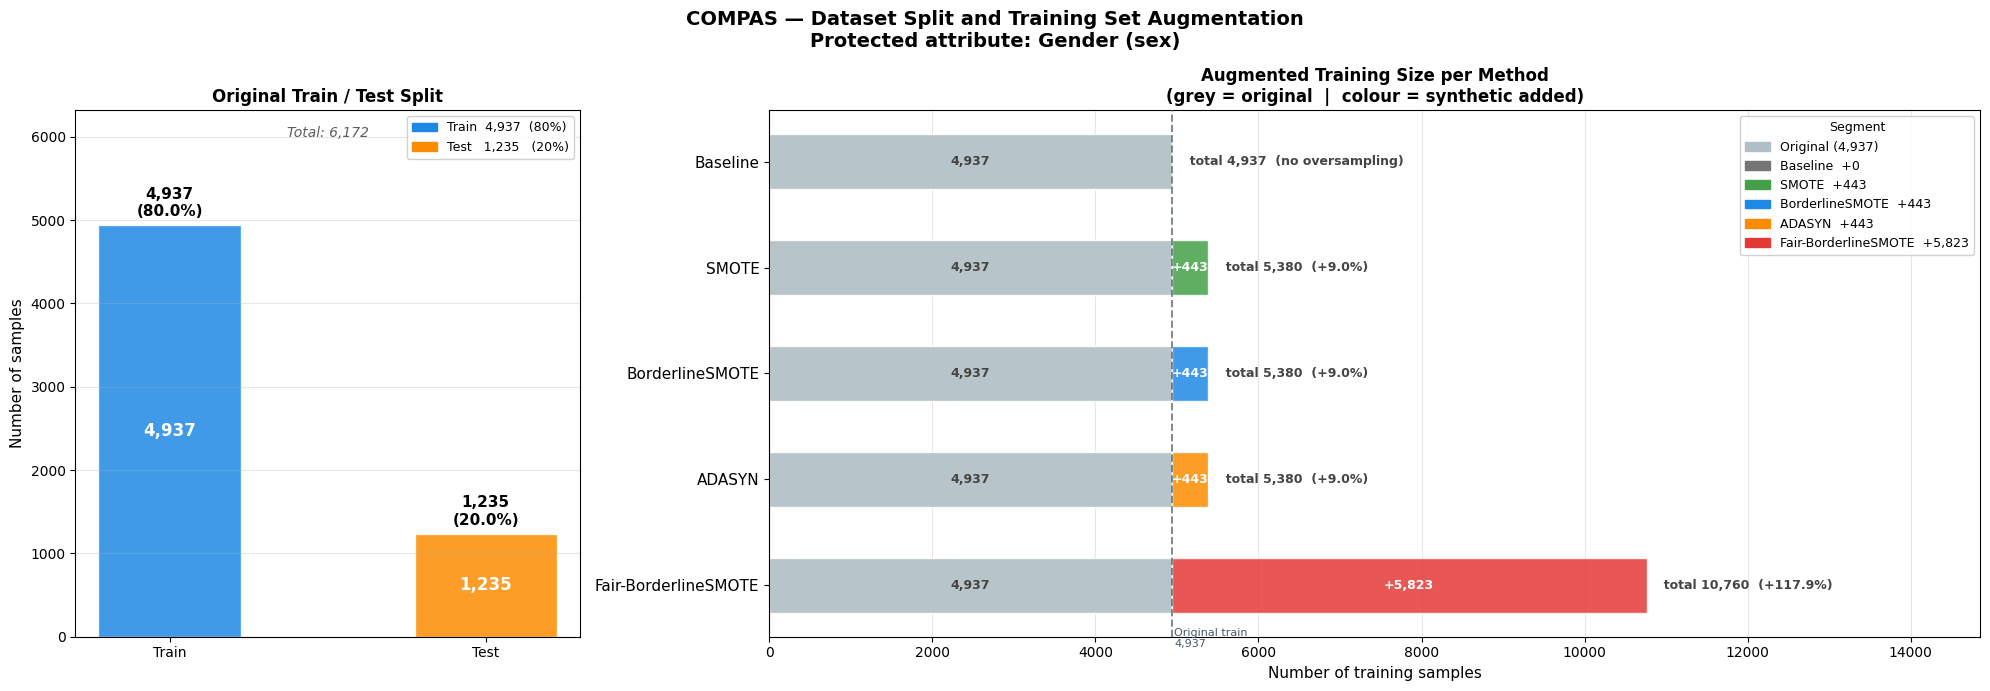

Saved plot_train_test_augmentation.png


In [ ]:
# ============================================================================
# Horizontal stacked bar — original vs synthetic per method
# + vertical bar — original train and test size
# =============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Pull values directly from results_df ──
summary = (results_df
           .groupby('oversampler', observed=True)
           .agg(
               n_synthetic=('n_synthetic', 'first'),
               train_orig  =('train_orig',  'first'),
               train_aug   =('train_aug',   'first'),
           )
           .reindex(OS_ORDER)
           .reset_index())

methods     = summary['oversampler'].tolist()
n_orig      = summary['train_orig'].tolist()
n_synthetic = summary['n_synthetic'].tolist()
n_aug       = summary['train_aug'].tolist()
train_orig  = int(summary['train_orig'].iloc[0])
test_size   = len(X_te_sc)
total_size  = train_orig + test_size

bar_colors   = ['#757575', '#43A047', '#1E88E5', '#FB8C00', '#E53935']
orig_color   = '#B0BEC5'
synth_color_map = dict(zip(methods, bar_colors))

# ── Layout: 1 row, 2 columns ──
fig, (ax_vbar, ax_hbar) = plt.subplots(
    1, 2,
    figsize=(20, 7),
    gridspec_kw={'width_ratios': [1, 2.4]})

fig.suptitle(
    'COMPAS — Dataset Split and Training Set Augmentation\n'
    'Protected attribute: Gender (sex)',
    fontsize=14, fontweight='bold')


# ------------------------------------------------------------------------------
# LEFT: vertical bar — original train vs test
# ------------------------------------------------------------------------------
split_vals   = [train_orig, test_size]
split_labels = ['Train', 'Test']
split_colors = ['#1E88E5', '#FB8C00']
split_pcts   = [train_orig / total_size * 100,
                test_size  / total_size * 100]

bars_v = ax_vbar.bar(
    split_labels, split_vals,
    color=split_colors, alpha=0.85,
    edgecolor='white', width=0.45)

ax_vbar.set_title('Original Train / Test Split',
                   fontweight='bold', fontsize=12)
ax_vbar.set_ylabel('Number of samples', fontsize=11)
ax_vbar.grid(axis='y', alpha=0.3)
ax_vbar.set_ylim(0, max(split_vals) * 1.28)

for bar, cnt, pct in zip(bars_v, split_vals, split_pcts):
    # Count + % on top of bar
    ax_vbar.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(split_vals) * 0.015,
        f'{cnt:,}\n({pct:.1f}%)',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold')
    # Count inside bar
    ax_vbar.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f'{cnt:,}',
        ha='center', va='center',
        fontsize=12, fontweight='bold',
        color='white')

# Total annotation
ax_vbar.text(
    0.5, 0.97,
    f'Total: {total_size:,}',
    transform=ax_vbar.transAxes,
    ha='center', va='top',
    fontsize=10, color='#5F5E5A',
    style='italic')

train_patch = mpatches.Patch(
    color='#1E88E5',
    label=f'Train  {train_orig:,}  ({train_orig/total_size*100:.0f}%)')
test_patch  = mpatches.Patch(
    color='#FB8C00',
    label=f'Test   {test_size:,}   ({test_size/total_size*100:.0f}%)')
ax_vbar.legend(handles=[train_patch, test_patch],
               loc='upper right', fontsize=9, framealpha=0.9)


# ------------------------------------------------------------------------------
# RIGHT: horizontal stacked bar — original + synthetic per method
# ------------------------------------------------------------------------------
y = np.arange(len(methods))
h = 0.52

# Original segment (grey)
ax_hbar.barh(y, n_orig, height=h,
              color=orig_color, alpha=0.9,
              edgecolor='white', zorder=2)

# Synthetic segment (method colour)
ax_hbar.barh(y, n_synthetic, height=h,
              left=n_orig,
              color=[synth_color_map[m] for m in methods],
              alpha=0.85,
              edgecolor='white', zorder=2)

# Labels
for i, (orig, synth, aug) in enumerate(zip(n_orig, n_synthetic, n_aug)):
    # Original count inside grey segment
    ax_hbar.text(
        orig / 2, i,
        f'{orig:,}',
        ha='center', va='center',
        fontsize=9, fontweight='bold',
        color='#444441', zorder=3)

    # Synthetic count inside coloured segment (only if wide enough)
    if synth > 300:
        ax_hbar.text(
            orig + synth / 2, i,
            f'+{synth:,}',
            ha='center', va='center',
            fontsize=9, fontweight='bold',
            color='white', zorder=3)

    # Total + % increase to the right of bar
    pct_label = (f'  total {aug:,}  (+{synth/orig*100:.1f}%)'
                 if synth > 0 else f'  total {aug:,}  (no oversampling)')
    ax_hbar.text(
        aug + max(n_aug) * 0.01, i,
        pct_label,
        ha='left', va='center',
        fontsize=9, fontweight='bold',
        color='#444441', zorder=3)

# Reference line — original train size
ax_hbar.axvline(train_orig, color='#455A64', linewidth=1.4,
                linestyle='--', alpha=0.7, zorder=4)
ax_hbar.text(
    train_orig + max(n_aug) * 0.003,
    len(methods) - 0.6,
    f'Original train\n{train_orig:,}',
    fontsize=8, color='#455A64', va='top')

ax_hbar.set_yticks(y)
ax_hbar.set_yticklabels(methods, fontsize=11)
ax_hbar.set_xlabel('Number of training samples', fontsize=11)
ax_hbar.set_xlim(0, max(n_aug) * 1.38)
ax_hbar.grid(axis='x', alpha=0.3)
ax_hbar.invert_yaxis()
ax_hbar.set_title(
    'Augmented Training Size per Method\n'
    '(grey = original  |  colour = synthetic added)',
    fontweight='bold', fontsize=12)

# Legend
orig_patch    = mpatches.Patch(color=orig_color,
                                label=f'Original ({train_orig:,})')
synth_patches = [
    mpatches.Patch(color=synth_color_map[m],
                   label=f'{m}  +{s:,}')
    for m, s in zip(methods, n_synthetic)
]
ax_hbar.legend(
    handles=[orig_patch] + synth_patches,
    loc='upper right', fontsize=9,
    title='Segment', title_fontsize=9,
    framealpha=0.9)

plt.tight_layout()
plt.savefig('plot_train_test_augmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved plot_train_test_augmentation.png')

---
## 7. Results Tables


In [ ]:
# Performance metrics
print('COMPAS — Performance Metrics')
display(results_df
        .set_index(['classifier','oversampler'])
        [['f1','auc','accuracy','precision','recall']]
        .round(4))

# Fairness metrics
print('\nCOMPAS — Gender Fairness Metrics')
display(results_df
        .set_index(['classifier','oversampler'])
        [['dp_diff','tpr_diff','fpr_diff']]
        .round(4))

# Per-gender rates
print('\nCOMPAS — Positive Prediction Rate & TPR by Gender')
display(results_df
        .set_index(['classifier','oversampler'])
        [['rate_female','rate_male','tpr_female','tpr_male','fpr_female','fpr_male']]
        .round(4))


COMPAS — Performance Metrics


f1     auc  accuracy  precision  \
classifier          oversampler                                                 
Logistic Regression Baseline              0.6094  0.7330    0.6834     0.6948   
                    SMOTE                 0.6482  0.7327    0.6818     0.6523   
                    BorderlineSMOTE       0.6597  0.7340    0.6842     0.6473   
                    ADASYN                0.6482  0.7327    0.6818     0.6523   
                    Fair-BorderlineSMOTE  0.6359  0.7257    0.6802     0.6597   
Random Forest       Baseline              0.5959  0.6863    0.6486     0.6250   
                    SMOTE                 0.6154  0.6857    0.6518     0.6187   
                    BorderlineSMOTE       0.6136  0.6868    0.6583     0.6321   
                    ADASYN                0.6154  0.6857    0.6518     0.6187   
                    Fair-BorderlineSMOTE  0.5855  0.6727    0.6251     0.5892   
XGBoost             Baseline              0.5956  0.7063    0.6713     0.6765   
                    SMOTE                 0.6135  0.7047    0.6623     0.6402   
                    BorderlineSMOTE       0.6144  0.7034    0.6615     0.6379   
                    ADASYN                0.6135  0.7047    0.6623     0.6402   
                    Fair-BorderlineSMOTE  0.6133  0.7046    0.6599     0.6355   

                                          recall  
classifier          oversampler                   
Logistic Regression Baseline              0.5427  
                    SMOTE                 0.6441  
                    BorderlineSMOTE       0.6726  
                    ADASYN                0.6441  
                    Fair-BorderlineSMOTE  0.6139  
Random Forest       Baseline              0.5694  
                    SMOTE                 0.6121  
                    BorderlineSMOTE       0.5961  
                    ADASYN                0.6121  
                    Fair-BorderlineSMOTE  0.5819  
XGBoost             Baseline              0.5320  
                    SMOTE                 0.5890  
                    BorderlineSMOTE       0.5925  
                    ADASYN                0.5890  
                    Fair-BorderlineSMOTE  0.5925


COMPAS — Gender Fairness Metrics


dp_diff  tpr_diff  fpr_diff
classifier          oversampler                                      
Logistic Regression Baseline               0.2900    0.3206    0.2119
                    SMOTE                  0.3423    0.3154    0.2983
                    BorderlineSMOTE        0.3660    0.3489    0.3144
                    ADASYN                 0.3423    0.3154    0.2983
                    Fair-BorderlineSMOTE   0.0512    0.0441    0.0074
Random Forest       Baseline               0.1777    0.1857    0.1232
                    SMOTE                  0.1846    0.1806    0.1353
                    BorderlineSMOTE        0.2116    0.2033    0.1636
                    ADASYN                 0.1846    0.1806    0.1353
                    Fair-BorderlineSMOTE   0.1889    0.2004    0.1398
XGBoost             Baseline               0.1925    0.1833    0.1425
                    SMOTE                  0.2303    0.2226    0.1811
                    BorderlineSMOTE        0.2247    0.1991    0.1868
                    ADASYN                 0.2303    0.2226    0.1811
                    Fair-BorderlineSMOTE   0.1421    0.1298    0.0953


COMPAS — Positive Prediction Rate & TPR by Gender


rate_female  rate_male  tpr_female  \
classifier          oversampler                                                
Logistic Regression Baseline                   0.1202     0.4102      0.2706   
                    SMOTE                      0.1717     0.5140      0.3765   
                    BorderlineSMOTE            0.1760     0.5419      0.3765   
                    ADASYN                     0.1717     0.5140      0.3765   
                    Fair-BorderlineSMOTE       0.3820     0.4331      0.5765   
Random Forest       Baseline                   0.2704     0.4481      0.4118   
                    SMOTE                      0.3004     0.4850      0.4588   
                    BorderlineSMOTE            0.2575     0.4691      0.4235   
                    ADASYN                     0.3004     0.4850      0.4588   
                    Fair-BorderlineSMOTE       0.2961     0.4850      0.4118   
XGBoost             Baseline                   0.2017     0.3942      0.3765   
                    SMOTE                      0.2318     0.4621      0.4000   
                    BorderlineSMOTE            0.2403     0.4651      0.4235   
                    ADASYN                     0.2318     0.4621      0.4000   
                    Fair-BorderlineSMOTE       0.3090     0.4511      0.4824   

                                          tpr_male  fpr_female  fpr_male  
classifier          oversampler                                           
Logistic Regression Baseline                0.5912      0.0338    0.2457  
                    SMOTE                   0.6918      0.0541    0.3524  
                    BorderlineSMOTE         0.7254      0.0608    0.3752  
                    ADASYN                  0.6918      0.0541    0.3524  
                    Fair-BorderlineSMOTE    0.6205      0.2703    0.2629  
Random Forest       Baseline                0.5975      0.1892    0.3124  
                    SMOTE                   0.6394      0.2095    0.3448  
                    BorderlineSMOTE         0.6268      0.1622    0.3257  
                    ADASYN                  0.6394      0.2095    0.3448  
                    Fair-BorderlineSMOTE    0.6122      0.2297    0.3695  
XGBoost             Baseline                0.5597      0.1014    0.2438  
                    SMOTE                   0.6226      0.1351    0.3162  
                    BorderlineSMOTE         0.6226      0.1351    0.3219  
                    ADASYN                  0.6226      0.1351    0.3162  
                    Fair-BorderlineSMOTE    0.6122      0.2095    0.3048

In [ ]:
# Summary averaged across classifiers
print('Summary — averaged across all three classifiers:')
summary = (results_df
           .groupby('oversampler', observed=True)
           [['f1','auc','accuracy','precision','recall',
             'dp_diff','tpr_diff','fpr_diff',
             'rate_female','rate_male','tpr_female','tpr_male']]
           .mean().round(4))
display(summary)


Summary — averaged across all three classifiers:


,f1,auc,accuracy,precision,recall,dp_diff,tpr_diff,fpr_diff,rate_female,rate_male,tpr_female,tpr_male
oversampler,,,,,,,,,,,,
Baseline,0.6003,0.7085,0.6678,0.6654,0.5480,0.2201,0.2299,0.1592,0.1974,0.4175,0.3529,0.5828
SMOTE,0.6257,0.7077,0.6653,0.6371,0.6151,0.2524,0.2395,0.2049,0.2346,0.4870,0.4118,0.6513
BorderlineSMOTE,0.6292,0.7081,0.6680,0.6391,0.6204,0.2674,0.2504,0.2216,0.2246,0.4920,0.4078,0.6583
ADASYN,0.6257,0.7077,0.6653,0.6371,0.6151,0.2524,0.2395,0.2049,0.2346,0.4870,0.4118,0.6513
Fair-BorderlineSMOTE,0.6116,0.7010,0.6551,0.6281,0.5961,0.1274,0.1248,0.0808,0.3290,0.4564,0.4902,0.6150


###Heatmap: Summary averaged across classifiers

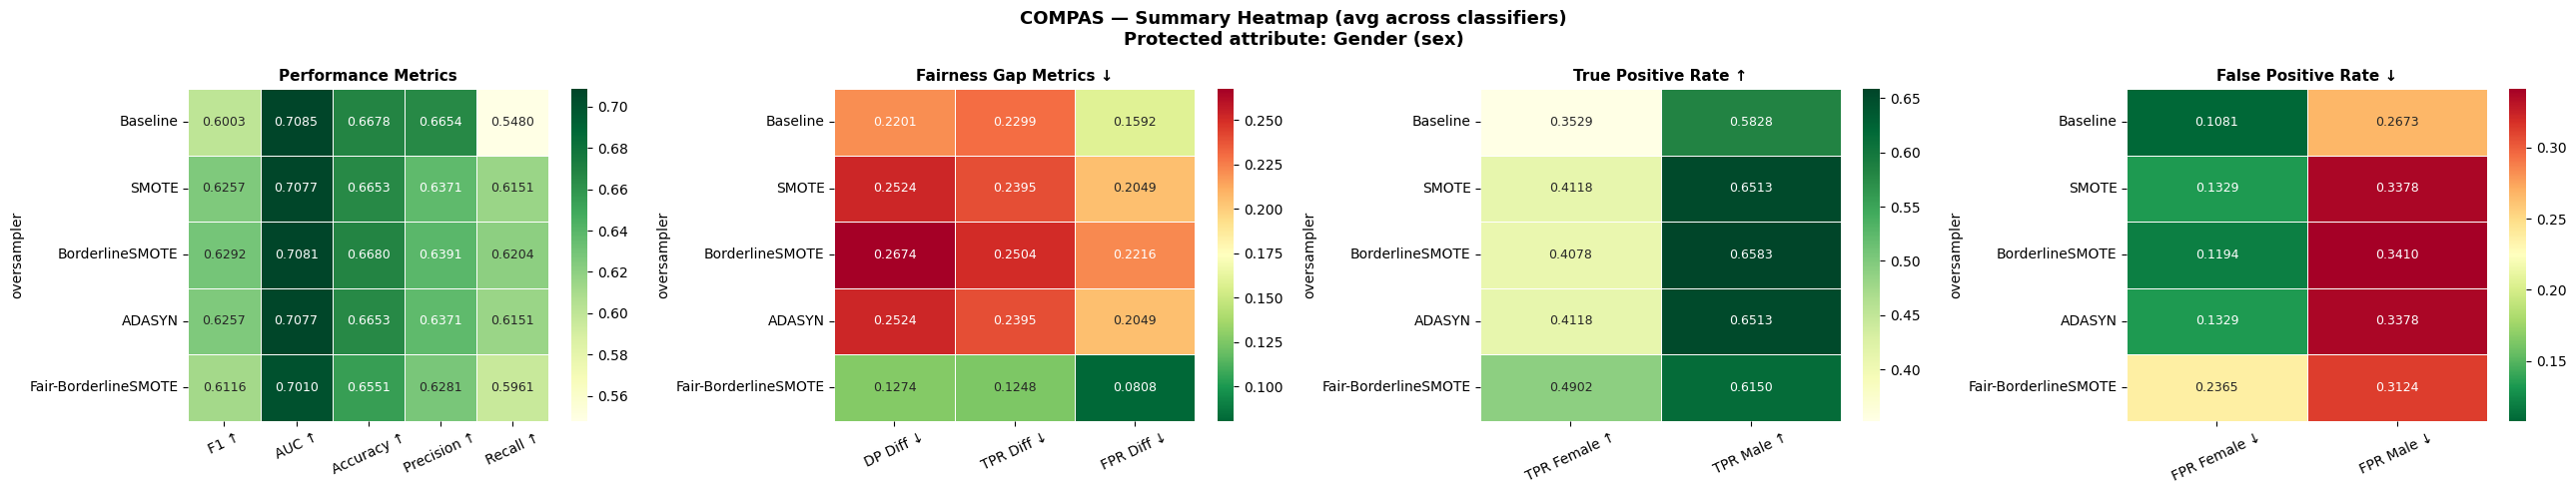

Saved plot_summary_heatmap.png


In [ ]:
# Summary heatmap averaged across classifiers
summary = (results_df
           .groupby('oversampler', observed=True)
           [['f1', 'auc', 'accuracy', 'precision', 'recall',
             'dp_diff', 'tpr_diff', 'fpr_diff',
             'tpr_female', 'tpr_male', 'fpr_female', 'fpr_male']]
           .mean().round(4)
           .reindex(OS_ORDER))

# Rename columns for display
summary.columns = [
    'F1 ↑', 'AUC ↑', 'Accuracy ↑', 'Precision ↑', 'Recall ↑',
    'DP Diff ↓', 'TPR Diff ↓', 'FPR Diff ↓',
    'TPR Female ↑', 'TPR Male ↑', 'FPR Female ↓', 'FPR Male ↓',
]

# Split into two groups for separate colormaps
perf_cols      = ['F1 ↑', 'AUC ↑', 'Accuracy ↑', 'Precision ↑', 'Recall ↑']
fairness_cols  = ['DP Diff ↓', 'TPR Diff ↓', 'FPR Diff ↓']
tpr_cols       = ['TPR Female ↑', 'TPR Male ↑']
fpr_cols       = ['FPR Female ↓', 'FPR Male ↓']

fig, axes = plt.subplots(1, 4, figsize=(26, 5))
fig.suptitle(
    'COMPAS — Summary Heatmap (avg across classifiers)\n'
    'Protected attribute: Gender (sex)',
    fontsize=13, fontweight='bold')

heatmap_specs = [
    (perf_cols,     'Performance Metrics',        'YlGn',    '.4f'),
    (fairness_cols, 'Fairness Gap Metrics ↓',     'RdYlGn_r','.4f'),
    (tpr_cols,      'True Positive Rate ↑',        'YlGn',    '.4f'),
    (fpr_cols,      'False Positive Rate ↓',       'RdYlGn_r','.4f'),
]

for ax, (cols, title, cmap, fmt) in zip(axes, heatmap_specs):
    sns.heatmap(
        summary[cols],
        ax=ax,
        annot=True,
        fmt=fmt,
        cmap=cmap,
        linewidths=0.5,
        annot_kws={'size': 9},
        cbar=True,
    )
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('plot_summary_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved plot_summary_heatmap.png')

---
## 8. Visualisations


In [ ]:
COLORS = {
    'Baseline':             '#757575',
    'SMOTE':                '#43A047',
    'BorderlineSMOTE':      '#1E88E5',
    'ADASYN':               '#FB8C00',
    'Fair-BorderlineSMOTE': '#E53935',
}
CLF_COLORS = ['#1565C0', '#2E7D32', '#E65100']
print('Palette ready.')


Palette ready.


###Plot 1: F1, Dem. Parity, EO TPR, EO FPR across classifiers

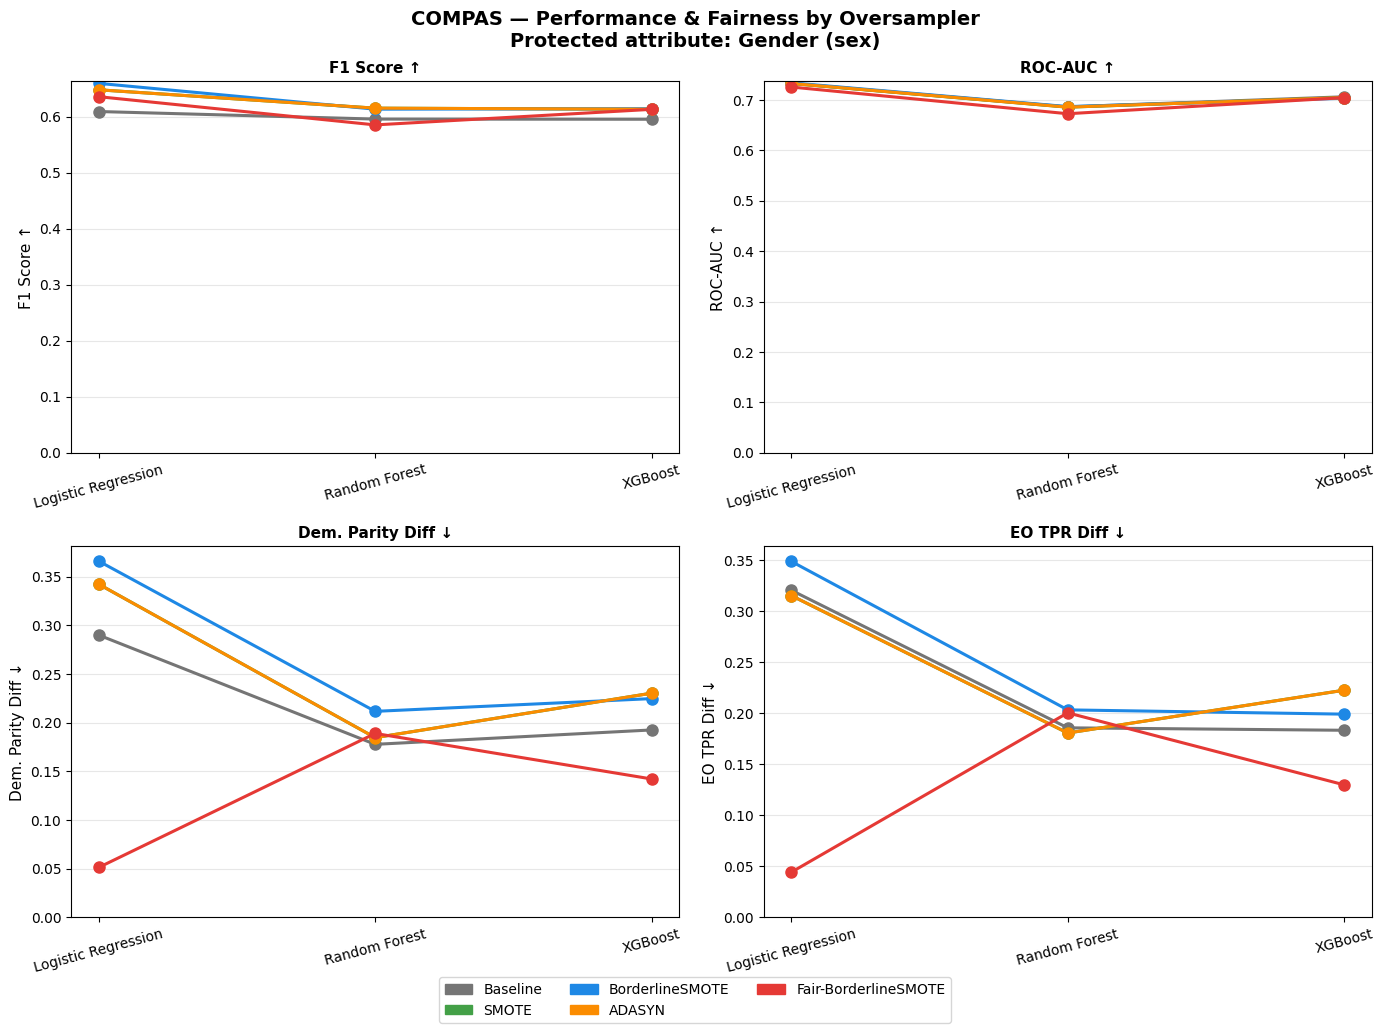

Saved plot_lines.png


In [ ]:
# Plot 1: F1, Dem. Parity, EO TPR, EO FPR across classifiers
metrics_plot = [
    ('f1',       'F1 Score ↑'),
    ('auc',      'ROC-AUC ↑'),
    ('dp_diff',  'Dem. Parity Diff ↓'),
    ('tpr_diff', 'EO TPR Diff ↓'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'COMPAS — Performance & Fairness by Oversampler\n'
    'Protected attribute: Gender (sex)',
    fontsize=14, fontweight='bold')

for ax, (metric, ylabel) in zip(axes.flat, metrics_plot):
    for os_n in OS_ORDER:
        vals = [
            results_df[
                (results_df['oversampler'] == os_n) &
                (results_df['classifier']  == c)
            ][metric].values
            for c in CLF_ORDER
        ]
        means = [v[0] if len(v) else np.nan for v in vals]
        ax.plot(CLF_ORDER, means, marker='o',
                color=COLORS[os_n], label=os_n,
                linewidth=2.2, markersize=8)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(ylabel, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    ax.set_ylim(bottom=0)
    ax.grid(axis='y', alpha=0.3)

handles = [mpatches.Patch(color=COLORS[o], label=o) for o in OS_ORDER]
fig.legend(handles=handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.04), fontsize=10)
plt.tight_layout()
plt.savefig('plot_lines.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved plot_lines.png')


### Plot 2: Heatmap — oversampler x metric (avg across classifiers)

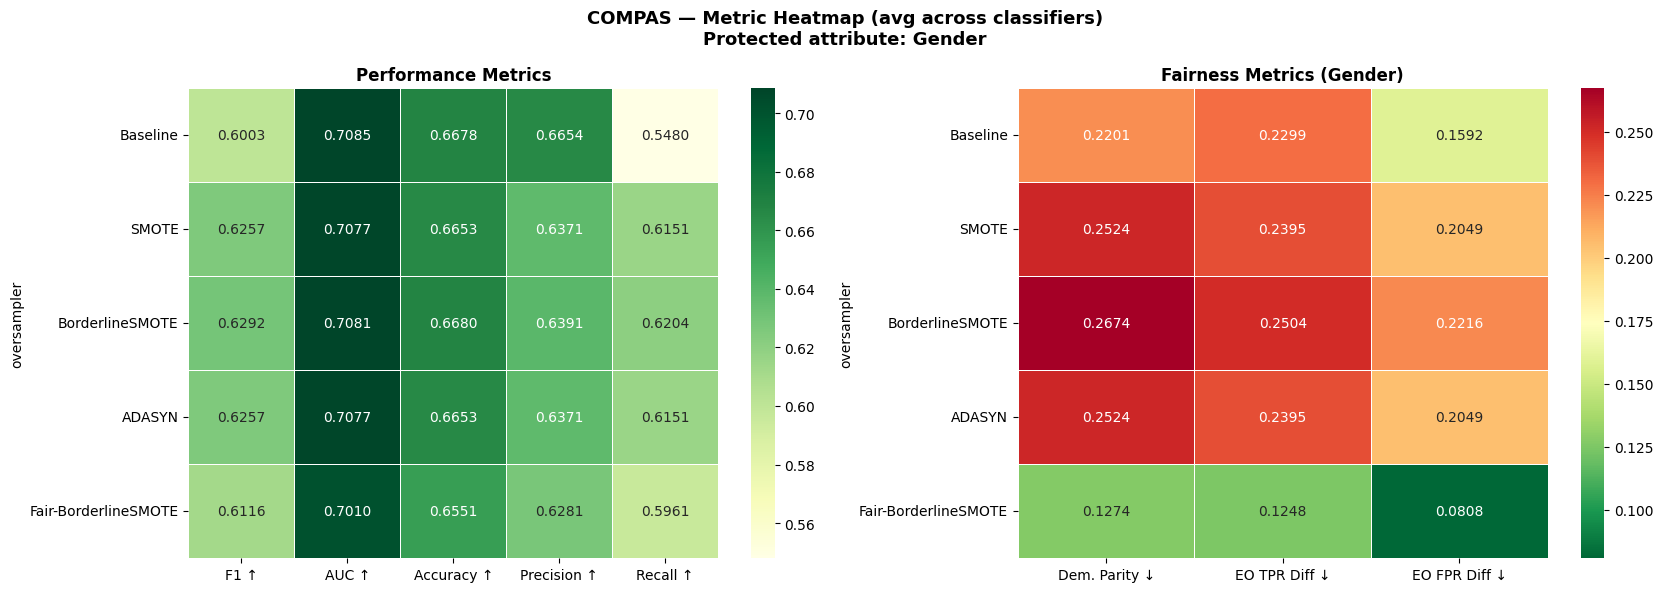

Saved plot_heatmap.png


In [ ]:
# Plot 2: Heatmap — oversampler x metric (avg across classifiers)
heat_metrics = ['f1', 'auc', 'accuracy', 'precision', 'recall',
                'dp_diff', 'tpr_diff', 'fpr_diff']
heat_labels  = ['F1 ↑', 'AUC ↑', 'Accuracy ↑', 'Precision ↑', 'Recall ↑',
                'Dem. Parity ↓', 'EO TPR Diff ↓', 'EO FPR Diff ↓']

heat_data = (results_df
             .groupby('oversampler', observed=True)[heat_metrics]
             .mean().reindex(OS_ORDER).round(4))
heat_data.columns = heat_labels

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle(
    'COMPAS — Metric Heatmap (avg across classifiers)\n'
    'Protected attribute: Gender',
    fontsize=13, fontweight='bold')

# Left: performance (5 metrics)
sns.heatmap(heat_data[heat_labels[:5]], ax=axes[0],
            annot=True, fmt='.4f', cmap='YlGn',
            linewidths=0.5, annot_kws={'size': 10})
axes[0].set_title('Performance Metrics', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='y', rotation=0)

# Right: fairness (3 metrics)
sns.heatmap(heat_data[heat_labels[5:]], ax=axes[1],
            annot=True, fmt='.4f', cmap='RdYlGn_r',
            linewidths=0.5, annot_kws={'size': 10})
axes[1].set_title('Fairness Metrics (Gender)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('plot_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved plot_heatmap.png')

###Plot 3: Grouped bar — F1, AUC, Accuracy, Precision, Recall, Dem. Parity, EO TPR Diff, EO FPR Diff

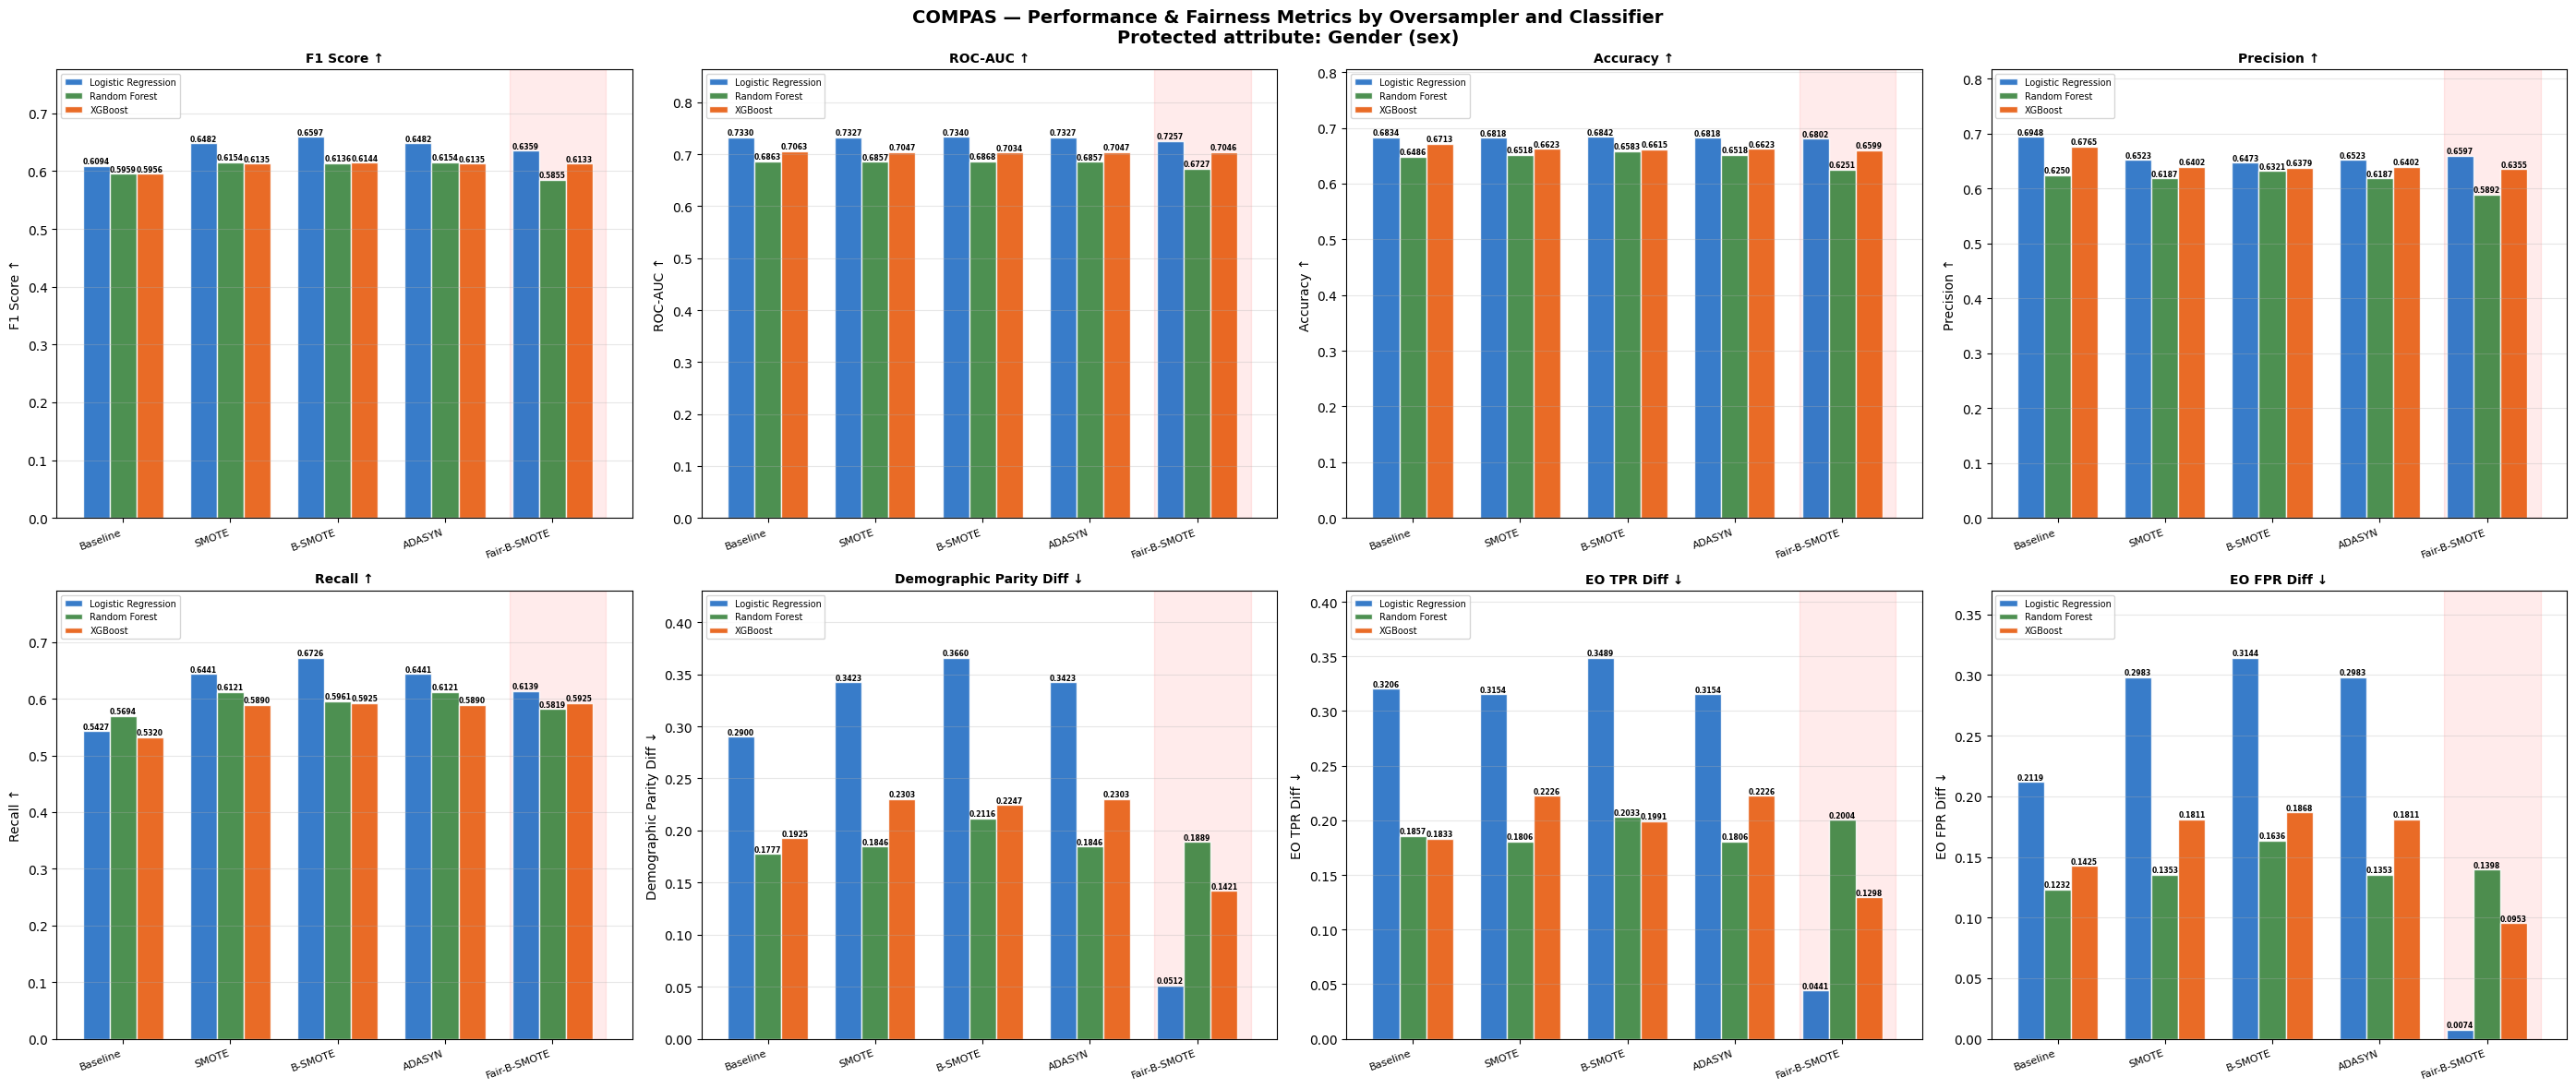

Saved plot_bars.png


In [ ]:
# Plot 3: Grouped bar — F1, AUC, Accuracy, Precision, Recall, Dem. Parity, EO TPR Diff, EO FPR Diff
short_labels = [
    o.replace('Fair-BorderlineSMOTE', 'Fair-B-SMOTE')
     .replace('BorderlineSMOTE', 'B-SMOTE')
    for o in OS_ORDER
]

metric_specs = [
    ('f1',        'F1 Score ↑'),
    ('auc',       'ROC-AUC ↑'),
    ('accuracy',  'Accuracy ↑'),
    ('precision', 'Precision ↑'),
    ('recall',    'Recall ↑'),
    ('dp_diff',   'Demographic Parity Diff ↓'),
    ('tpr_diff',  'EO TPR Diff ↓'),
    ('fpr_diff',  'EO FPR Diff ↓'),
]

fig, axes = plt.subplots(2, 4, figsize=(28, 12))
fig.suptitle(
    'COMPAS — Performance & Fairness Metrics by Oversampler and Classifier\n'
    'Protected attribute: Gender (sex)',
    fontsize=14, fontweight='bold')

x = np.arange(len(OS_ORDER))
w = 0.25

for ax, (metric, ylabel) in zip(axes.flat, metric_specs):

    bar_data = (results_df
                .groupby(['oversampler', 'classifier'], observed=True)[metric]
                .mean()
                .unstack('classifier')
                .reindex(OS_ORDER)[CLF_ORDER])

    for i, (clf, col) in enumerate(zip(CLF_ORDER, CLF_COLORS)):
        bars = ax.bar(
            x + i * w,
            bar_data[clf],
            width=w,
            label=clf,
            color=col,
            alpha=0.85,
            edgecolor='white'
        )
        # Numeric labels on top of each bar
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + ax.get_ylim()[1] * 0.001,
                f'{height:.4f}',
                ha='center', va='bottom',
                fontsize=5.5, fontweight='bold'
            )

    # Highlight Fair-BorderlineSMOTE column (index 4)
    ax.axvspan(3.85, 4.75, alpha=0.08, color='red', zorder=0)

    ax.set_xticks(x + w)
    ax.set_xticklabels(short_labels, fontsize=8, rotation=20, ha='right')
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(ylabel, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(bottom=0)
    # Pad y-axis top so labels don't clip
    ax.set_ylim(top=ax.get_ylim()[1] * 1.12)

plt.tight_layout()
plt.savefig('plot_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved plot_bars.png')

###Plot 4: Per-gender positive prediction rate and TPR and FPR side by side

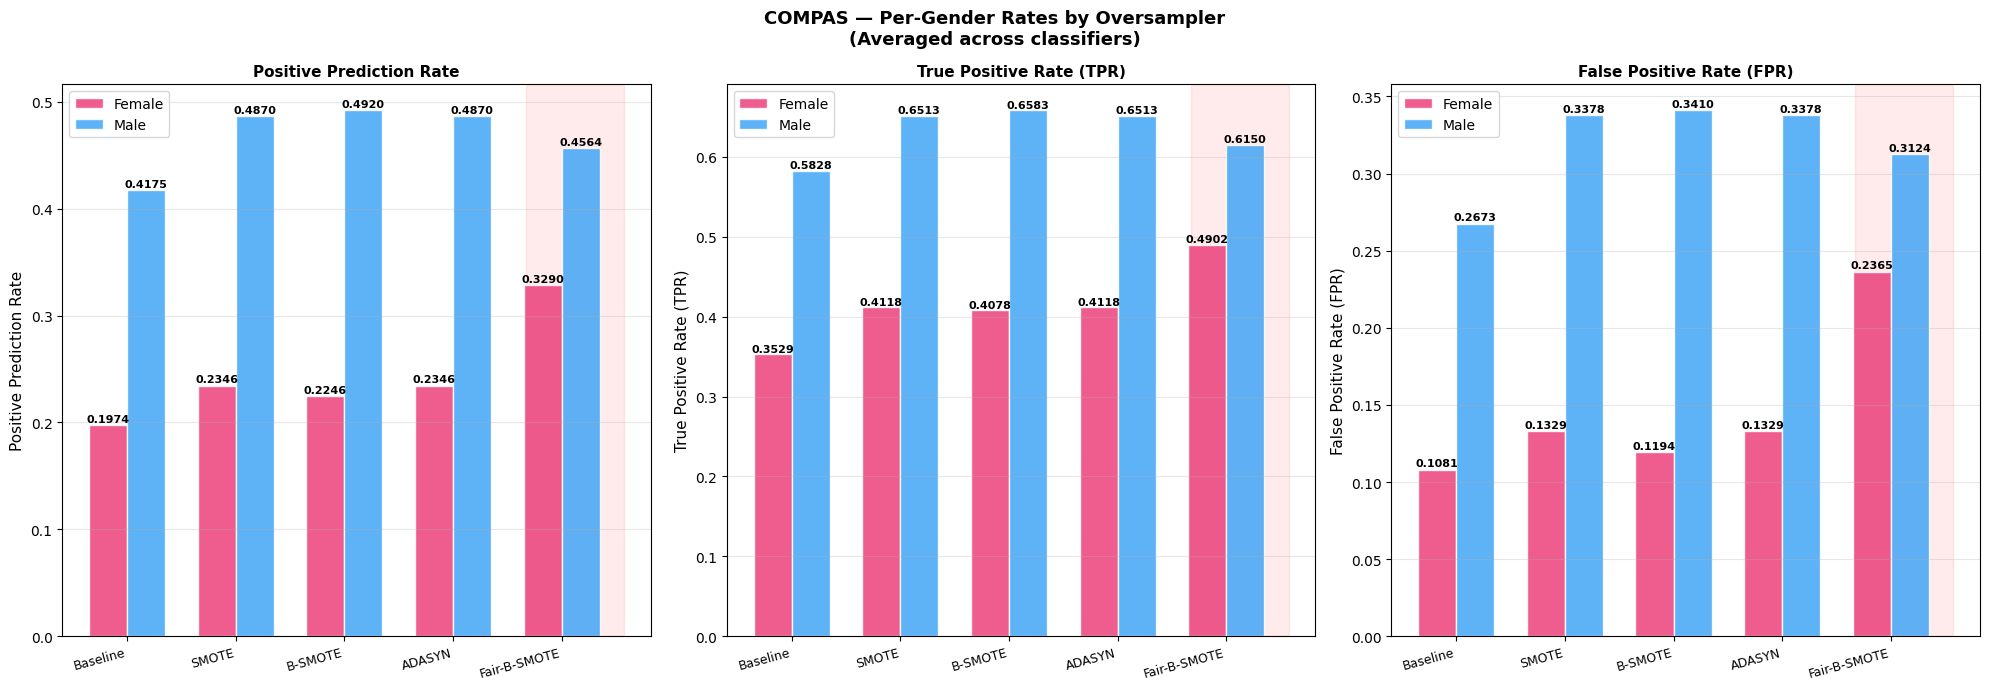

Saved plot_gender_rates.png


In [ ]:
# Plot 4: Per-gender positive prediction rate and TPR and FPR side by side
gender_metrics = [
    (['rate_female','rate_male'], 'Positive Prediction Rate'),
    (['tpr_female', 'tpr_male'],  'True Positive Rate (TPR)'),
    (['fpr_female', 'fpr_male'],  'False Positive Rate (FPR)'),
]

gender_colors = ['#EC407A', '#42A5F5']   # pink=Female, blue=Male
gender_labels = ['Female', 'Male']

x = np.arange(len(OS_ORDER))
w = 0.35

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

fig.suptitle(
    'COMPAS — Per-Gender Rates by Oversampler\n'
    '(Averaged across classifiers)',
    fontsize=13,
    fontweight='bold'
)

for ax, (cols, ylabel) in zip(axes, gender_metrics):
    grp = (results_df
           .groupby('oversampler', observed=True)[cols]
           .mean()
           .reindex(OS_ORDER))

    for i, (col, gc, gl) in enumerate(zip(cols, gender_colors, gender_labels)):
        bars = ax.bar(
            x + i*w,
            grp[col],
            width=w,
            label=gl,
            color=gc,
            alpha=0.85,
            edgecolor='white'
        )

        # Add numeric labels on top of bars
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.001,
                f'{height:.4f}',
                ha='center',
                va='bottom',
                fontsize=8,
                rotation=0,
                fontweight='bold'   # <-- makes numbers bold
            )

    ax.axvspan(3.85, 4.75, alpha=0.08, color='red', zorder=0)

    ax.set_xticks(x + w/2)
    ax.set_xticklabels(short_labels, fontsize=9, rotation=15, ha='right')

    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(ylabel, fontsize=11, fontweight='bold')

    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('plot_gender_rates.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved plot_gender_rates.png')

###Plot 5: Per-gender TPR and FPR side by side

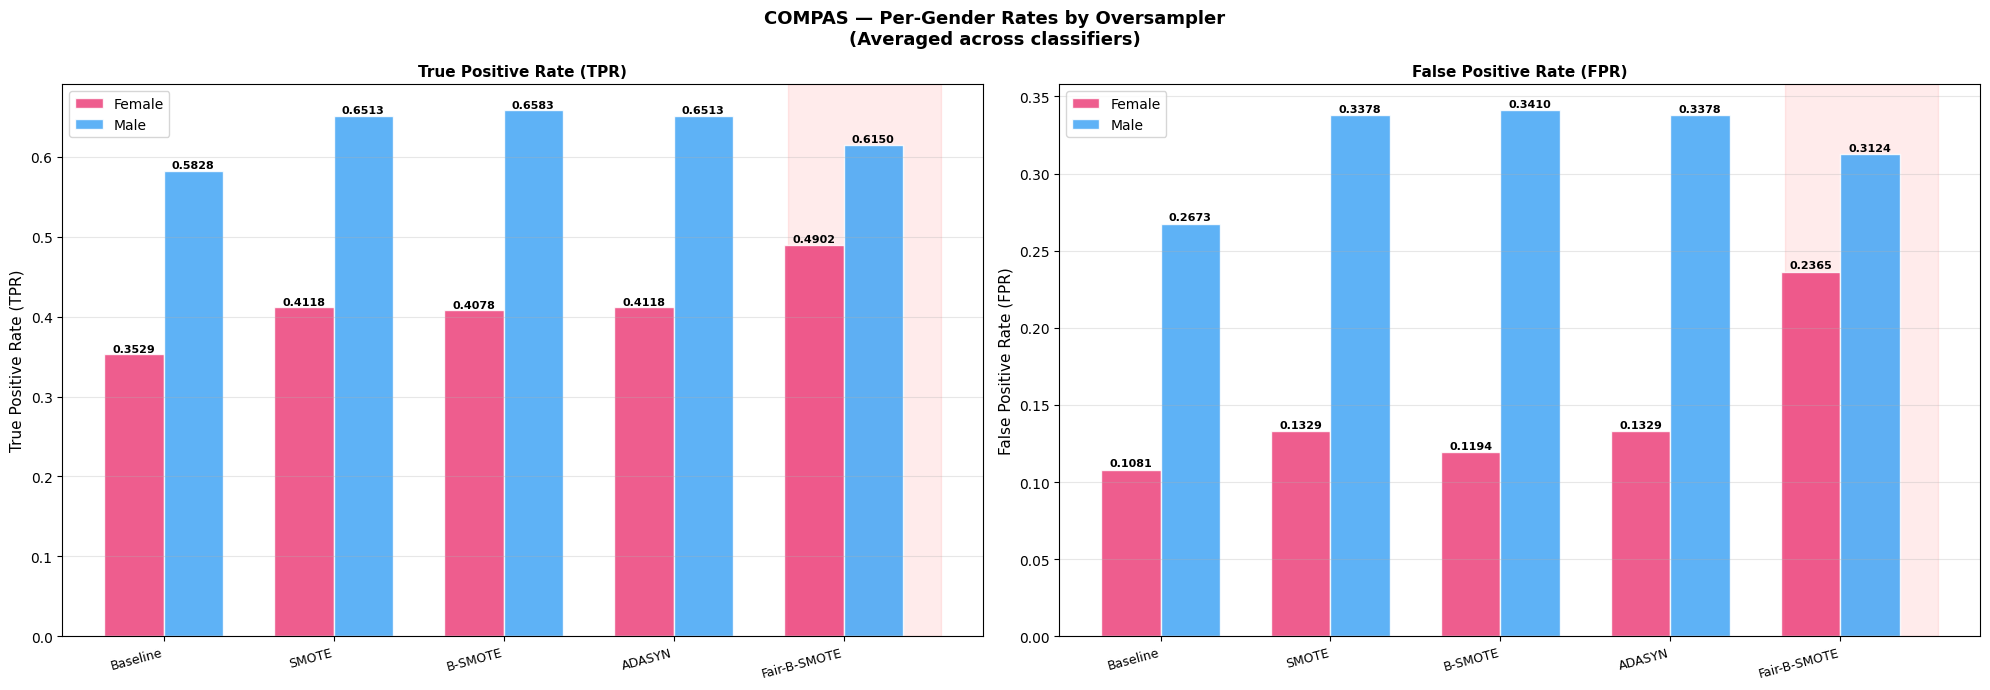

Saved plot_gender_rates.png


In [ ]:
# Plot 5: Per-gender TPR and FPR side by side
gender_metrics = [
    (['tpr_female', 'tpr_male'],  'True Positive Rate (TPR)'),
    (['fpr_female', 'fpr_male'],  'False Positive Rate (FPR)'),
]

gender_colors = ['#EC407A', '#42A5F5']   # pink=Female, blue=Male
gender_labels = ['Female', 'Male']

x = np.arange(len(OS_ORDER))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

fig.suptitle(
    'COMPAS — Per-Gender Rates by Oversampler\n'
    '(Averaged across classifiers)',
    fontsize=13,
    fontweight='bold'
)

for ax, (cols, ylabel) in zip(axes, gender_metrics):
    grp = (results_df
           .groupby('oversampler', observed=True)[cols]
           .mean()
           .reindex(OS_ORDER))

    for i, (col, gc, gl) in enumerate(zip(cols, gender_colors, gender_labels)):
        bars = ax.bar(
            x + i*w,
            grp[col],
            width=w,
            label=gl,
            color=gc,
            alpha=0.85,
            edgecolor='white'
        )

        # Add numeric labels on top of bars
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width()/2,
                height + 0.001,
                f'{height:.4f}',
                ha='center',
                va='bottom',
                fontsize=8,
                rotation=0,
                fontweight='bold'   # <-- makes numbers bold
            )

    ax.axvspan(3.85, 4.75, alpha=0.08, color='red', zorder=0)

    ax.set_xticks(x + w/2)
    ax.set_xticklabels(short_labels, fontsize=9, rotation=15, ha='right')

    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(ylabel, fontsize=11, fontweight='bold')

    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('plot_gender_rates.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved plot_gender_rates.png')

###Plot 6: Fair-BorderlineSMOTE synthesis log — borderline vs generated per subgroup

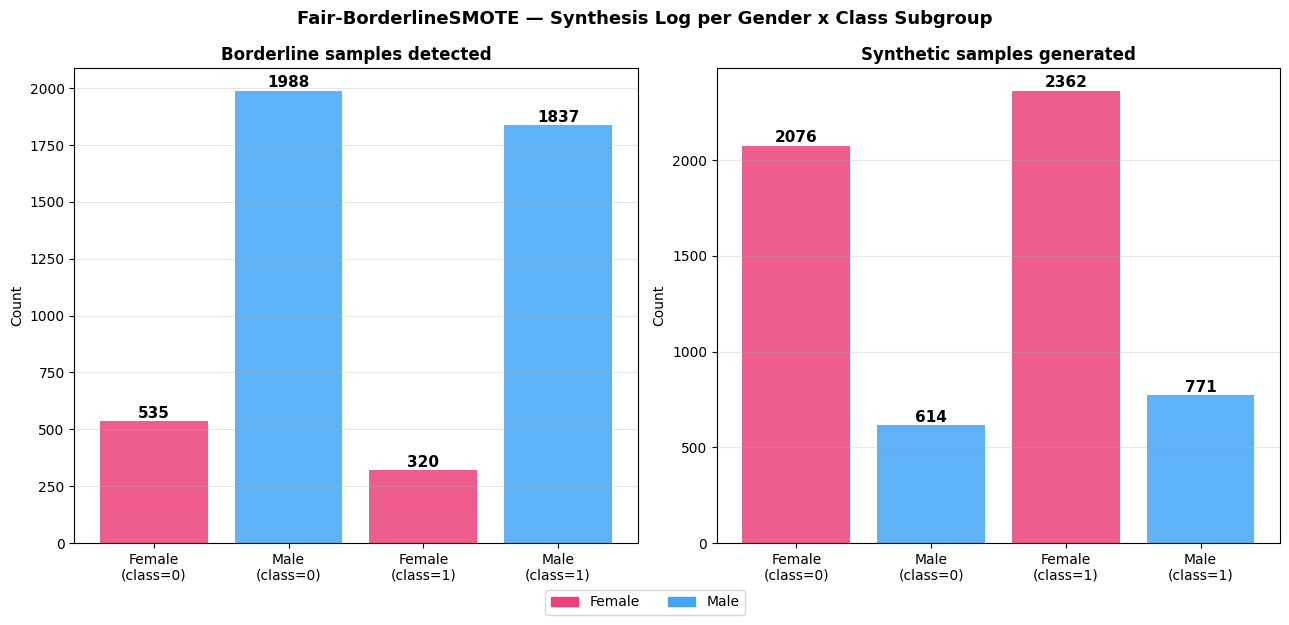

Saved plot_synthesis_log.png


In [ ]:
# Plot 6: Fair-BorderlineSMOTE synthesis log — borderline vs generated per subgroup
_, _, _, synth_log = fair_borderline_smote(X_tr_sc, y_tr, sex_tr, k=5, m=10)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle(
    'Fair-BorderlineSMOTE — Synthesis Log per Gender x Class Subgroup',
    fontsize=13, fontweight='bold')

synth_log['label'] = (synth_log['gender'] + '\n(class=' +
                      synth_log['class'].astype(str) + ')')

bar_colors = ['#EC407A', '#42A5F5', '#EC407A', '#42A5F5']

# Left: borderline samples detected
bars0 = axes[0].bar(synth_log['label'], synth_log['borderline'],
                    color=bar_colors, alpha=0.85)
axes[0].set_title('Borderline samples detected', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars0, synth_log['borderline']):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + axes[0].get_ylim()[1] * 0.001,
        str(int(val)),
        ha='center', va='bottom', fontsize=11, fontweight='bold')

# Right: synthetic samples generated
bars1 = axes[1].bar(synth_log['label'], synth_log['generated'],
                    color=bar_colors, alpha=0.85)
axes[1].set_title('Synthetic samples generated', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, synth_log['generated']):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + axes[1].get_ylim()[1] * 0.001,
        str(int(val)),
        ha='center', va='bottom', fontsize=11, fontweight='bold')

female_patch = mpatches.Patch(color='#EC407A', label='Female')
male_patch   = mpatches.Patch(color='#42A5F5', label='Male')
fig.legend(handles=[female_patch, male_patch], loc='lower center',
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
plt.savefig('plot_synthesis_log.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved plot_synthesis_log.png')

---
## 9. Export Results


In [ ]:
results_df.to_csv('compas_fair_bls_results.csv', index=False)
print(f'Results saved — {len(results_df)} rows  '
      f'({len(OVERSAMPLERS)} methods x {len(CLF_ORDER)} classifiers)')

print('\nSummary (avg across classifiers):')
display(results_df
        .groupby('oversampler', observed=True)
        [['f1', 'auc', 'accuracy','precision', 'recall',
          'dp_diff', 'tpr_diff', 'fpr_diff',
          'rate_female', 'rate_male']]
        .mean().round(4))

from google.colab import files
for fname in [
    'compas_fair_bls_results.csv',
    'plot_lines.png', 'plot_heatmap.png',
    'plot_bars.png',  'plot_gender_rates.png',
    'plot_synthesis_log.png',
]:
    try:
        files.download(fname)
    except Exception:
        print(f'  Could not auto-download {fname}')

Results saved — 15 rows  (5 methods x 3 classifiers)

Summary (avg across classifiers):


,f1,auc,accuracy,precision,recall,dp_diff,tpr_diff,fpr_diff,rate_female,rate_male
oversampler,,,,,,,,,,
Baseline,0.6003,0.7085,0.6678,0.6654,0.5480,0.2201,0.2299,0.1592,0.1974,0.4175
SMOTE,0.6257,0.7077,0.6653,0.6371,0.6151,0.2524,0.2395,0.2049,0.2346,0.4870
BorderlineSMOTE,0.6292,0.7081,0.6680,0.6391,0.6204,0.2674,0.2504,0.2216,0.2246,0.4920
ADASYN,0.6257,0.7077,0.6653,0.6371,0.6151,0.2524,0.2395,0.2049,0.2346,0.4870
Fair-BorderlineSMOTE,0.6116,0.7010,0.6551,0.6281,0.5961,0.1274,0.1248,0.0808,0.3290,0.4564


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 10. Metric Reference

### Performance

| Metric | Direction | Description |
|---|---|---|
| F1 Score | ↑ | Harmonic mean of precision and recall |
| ROC-AUC | ↑ | Discriminative ability, threshold-independent |
| Accuracy | ↑ | Overall fraction of correct predictions |
| Precision | ↑ | Fraction of predicted positives that are correct |
| Recall | ↑ | Fraction of actual positives correctly identified |

### Fairness (Gender)

| Metric | Direction | Description |
|---|---|---|
| Dem. Parity Diff | ↓ | Gap in positive prediction rates between male and female|P(ŷ=1|Male) − P(ŷ=1|Female)||
| EO TPR Diff | ↓ | True Positive Rate gap between Male and Female (equal opportunity) |
| EO FPR Diff | ↓ | False Positive Rate gap between Male and Female |

### Method comparison

| Method | Gender-aware | Mechanism |
|---|---|---|
| Baseline | ✗ | No resampling |
| SMOTE | ✗ | Interpolates between random minority-class neighbours |
| BorderlineSMOTE | ✗ | Focuses SMOTE synthesis on borderline minority samples |
| ADASYN | ✗ | Adaptive synthesis — more samples near harder instances |
| **Fair-BorderlineSMOTE** | **✓** | BorderlineSMOTE stratified by gender × class; within-group kNN guarantees no cross-gender interpolation |

### Fair-BorderlineSMOTE parameters

| Parameter | Value | Role |
|---|---|---|
| `k` | 5 | Within-group kNN neighbors used during synthesis |
| `m` | 10 | Full-dataset kNN neighbors used for borderline detection |
| `cr` | 0.8 | Crossover rate — probability of using interpolated value per feature |
| `f` | 0.8 | Scaling factor controlling interpolation step size |
